##  Задания 4 и 5 

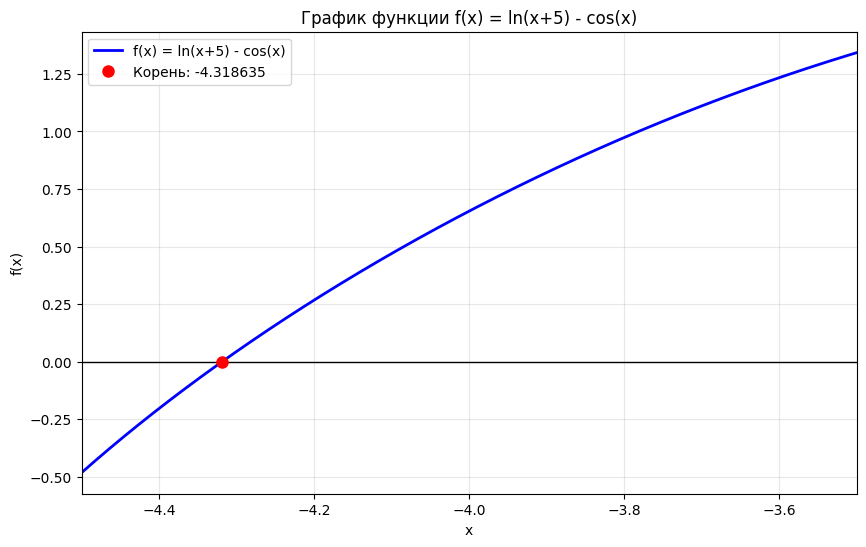

Корень: -4.3186353


In [10]:
from math import *
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    if x + 5 <= 0:
        return None
    return log(x + 5) - cos(x)

def f_prime(x):
    return 1/(x + 5) + sin(x)

def combined_method_chord_tangent(a, b, tol=1e-6, max_iter=100):
    if abs(f(a)) < abs(f(b)):
        x_newton = a
        x_chord = b
    else:
        x_newton = b
        x_chord = a
    
    for n in range(max_iter):
        x_tangent = x_newton - f(x_newton) / f_prime(x_newton)
        x_chord_new = x_chord - f(x_chord) * (x_chord - x_newton) / (f(x_chord) - f(x_newton))
        x_next = (x_tangent + x_chord_new) / 2
        
        if abs(x_next - x_newton) < tol and abs(x_next - x_chord) < tol:
            break
        
        if f(x_next) * f(x_newton) < 0:
            x_chord = x_newton
        else:
            x_chord = x_chord_new
        x_newton = x_next
    
    return x_next

a, b = -4.4, -4.3
root = combined_method_chord_tangent(a, b, tol=1e-6)

# График
x = np.linspace(-4.5, -3.5, 1000)
y = []
for xi in x:
    val = f(xi)
    if val is not None:
        y.append(val)
    else:
        y.append(np.nan)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='f(x) = ln(x+5) - cos(x)')
plt.axhline(y=0, color='k', linewidth=1)
plt.plot(root, f(root), 'ro', markersize=8, label=f'Корень: {root:.6f}')
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('График функции f(x) = ln(x+5) - cos(x)')
plt.xlim(-4.5, -3.5)
plt.legend()
plt.show()

print(f"Корень: {root:.7f}")

>##  Метод Брента (Brent's method) ##
>Это гибридный (комбинированный) метод поиска корня уравнения f(x)=0, который объединяет три метода: 
>
	>>1. Метод деления отрезка пополам (бисекция) — медленный, но гарантированно сходящийся. 
	>>2. Метод секущих (secant method) — быстрее, но может расходиться.
	>>3. Метод обратной квадратичной интерполяции (inverse quadratic interpolation) — ещё быстрее, но менее надёжен.
>
>>__Идея:__
>
>На каждом шаге Брент пытается применить быстрые методы (секущих или IQI), но если они ведут к нестабильности или выходу за пределы интервала, он "откатывается" к методу деления пополам, который гарантирует, что интервал с корнем будет уменьшаться.
Алгоритм (упрощённо):
>
	>>1. Задаётся начальный интервал [a,b], где f(a)⋅f(b)<0 (знаки разные — корень внутри).
	>>2. На каждой итерации:
>
	    >>>* Пытается применить обратную квадратичную интерполяцию или метод секущих, чтобы получить новое приближение c.
	    >>>* Если c лежит внутри интервала и сходимость "хорошая" — принимает c.
	    >>>* Если нет — делает шаг методом деления пополам: c=(a+b)/2.
>
	>>3. Обновляет интервал: новый [a,b] — это меньший отрезок, содержащий корень.
	>>4. Критерий остановки: ∣b-a∣<"точность"  или ∣f(c)∣<"точность" .


Корень: -4.3186353
Итераций: 7


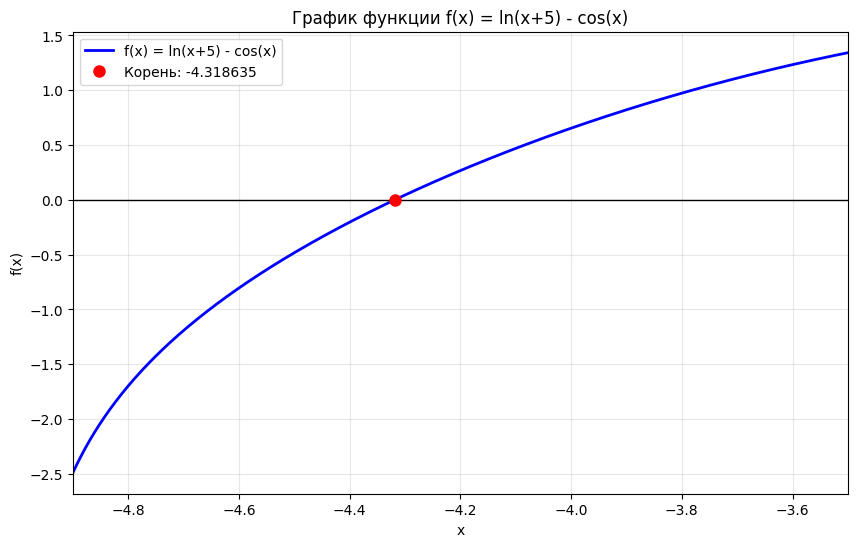

In [12]:
from scipy import optimize
from math import log, cos
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    if x + 5 <= 0:
        return 1000
    return log(x + 5) - cos(x)

result = optimize.root_scalar(f, bracket=[-4.9, -4], method='brentq')

print(f"Корень: {result.root:.7f}")
print(f"Итераций: {result.iterations}")

# График
x = np.linspace(-4.9, -3.5, 1000)
y = []
for xi in x:
    if xi + 5 > 0:
        y.append(log(xi + 5) - cos(xi))
    else:
        y.append(np.nan)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='f(x) = ln(x+5) - cos(x)')
plt.axhline(y=0, color='k', linewidth=1)
plt.plot(result.root, f(result.root), 'ro', markersize=8, label=f'Корень: {result.root:.6f}')
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('График функции f(x) = ln(x+5) - cos(x)')
plt.xlim(-4.9, -3.5)
plt.legend()
plt.show()